# Exercice 4 : Régression sur un dataset
## Comparaison de plusieurs méthodes de régression avec optimisation des hyperparamètres

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [49]:
# Chargement des données depuis les fichiers .npy
X_train = np.load('data/X_train.npy')
X_test = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test = np.load('data/y_test.npy')

print(f"Forme X_train : {X_train.shape}")
print(f"Forme X_test : {X_test.shape}")
print(f"Forme y_train : {y_train.shape}")
print(f"Forme y_test : {y_test.shape}")

Forme X_train : (200, 200)
Forme X_test : (200, 200)
Forme y_train : (200, 1)
Forme y_test : (200, 1)


Statistiques descriptives

X_train - Min: 0.0000, Max: 1.0000, Mean: 0.4984, Std: 0.2893
X_test - Min: 0.0000, Max: 1.0000, Mean: 0.4993, Std: 0.2891

y_train - Min: 1.9300, Max: 7.4648, Mean: 4.9068, Std: 0.9454
y_test - Min: 2.2818, Max: 7.4820, Mean: 5.0649, Std: 0.8580


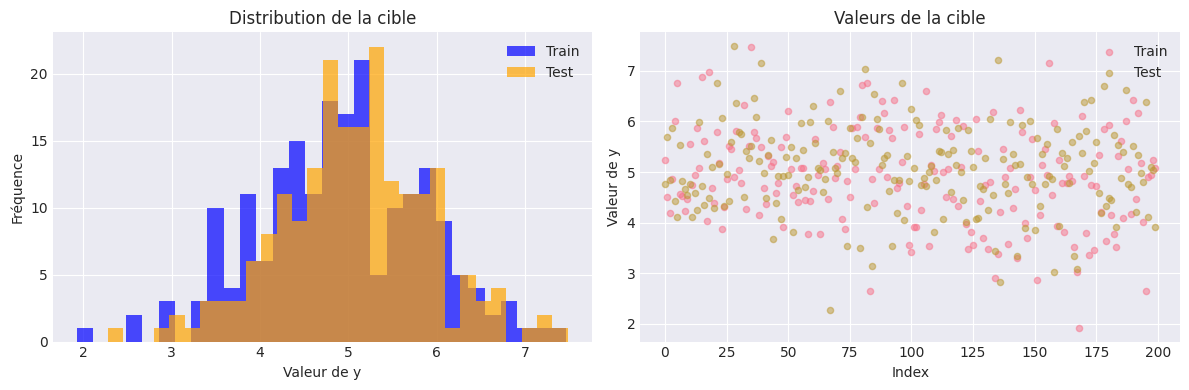

In [50]:
print("Statistiques descriptives")
print(f"\nX_train - Min: {X_train.min():.4f}, Max: {X_train.max():.4f}, Mean: {X_train.mean():.4f}, Std: {X_train.std():.4f}")
print(f"X_test - Min: {X_test.min():.4f}, Max: {X_test.max():.4f}, Mean: {X_test.mean():.4f}, Std: {X_test.std():.4f}")
print(f"\ny_train - Min: {y_train.min():.4f}, Max: {y_train.max():.4f}, Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"y_test - Min: {y_test.min():.4f}, Max: {y_test.max():.4f}, Mean: {y_test.mean():.4f}, Std: {y_test.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=30, alpha=0.7, label='Train', color='blue')
axes[0].hist(y_test, bins=30, alpha=0.7, label='Test', color='orange')
axes[0].set_xlabel('Valeur de y')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la cible')
axes[0].legend()

axes[1].scatter(range(len(y_train)), y_train, alpha=0.5, label='Train', s=20)
axes[1].scatter(range(len(y_test)), y_test, alpha=0.5, label='Test', s=20)
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Valeur de y')
axes[1].set_title('Valeurs de la cible')
axes[1].legend()
plt.tight_layout()
plt.show()

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données normalisées")
print(f"X_train_scaled - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"X_test_scaled - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")

Données normalisées
X_train_scaled - Mean: 0.000000, Std: 1.000000
X_test_scaled - Mean: 0.002503, Std: 1.007813


## Méthode 1 : Gradient Boosting Regressor

In [52]:
print("GRADIENT BOOSTING REGRESSOR")
print("Optimisation des hyperparamètres via GridSearchCV...\n")

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=42)
grid_search_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_gb.fit(X_train, y_train)

print(f"Meilleurs hyperparamètres : {grid_search_gb.best_params_}")
print(f"Meilleur score CV (R²) : {grid_search_gb.best_score_:.6f}")


GRADIENT BOOSTING REGRESSOR
Optimisation des hyperparamètres via GridSearchCV...

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Meilleurs hyperparamètres : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.8}
Meilleur score CV (R²) : 0.414443


In [53]:
gb_best = grid_search_gb.best_estimator_

y_train_pred_gb = gb_best.predict(X_train)
y_test_pred_gb = gb_best.predict(X_test)

r2_train_gb = r2_score(y_train, y_train_pred_gb)
r2_test_gb = r2_score(y_test, y_test_pred_gb)
mse_train_gb = mean_squared_error(y_train, y_train_pred_gb)
mse_test_gb = mean_squared_error(y_test, y_test_pred_gb)
mae_train_gb = mean_absolute_error(y_train, y_train_pred_gb)
mae_test_gb = mean_absolute_error(y_test, y_test_pred_gb)

print(f"\nRésultats Gradient Boosting")
print(f"Train - R²: {r2_train_gb:.6f}, MSE: {mse_train_gb:.6f}, MAE: {mae_train_gb:.6f}")
print(f"Test  - R²: {r2_test_gb:.6f}, MSE: {mse_test_gb:.6f}, MAE: {mae_test_gb:.6f}")


Résultats Gradient Boosting
Train - R²: 0.999086, MSE: 0.000817, MAE: 0.023240
Test  - R²: 0.619223, MSE: 0.280324, MAE: 0.418514


## Méthode 2 : Ridge Regression avec optimisation

In [54]:
print("\nRIDGE REGRESSION")
print("\nOptimisation des hyperparamètres via GridSearchCV...\n")

alphas = np.logspace(-3, 3, 50)

ridge = Ridge()
grid_search_ridge = GridSearchCV(
    ridge,
    {'alpha': alphas},
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_search_ridge.fit(X_train_scaled, y_train)

print(f"Meilleur alpha : {grid_search_ridge.best_params_['alpha']:.6f}")
print(f"Meilleur score CV (R²) : {grid_search_ridge.best_score_:.6f}")


RIDGE REGRESSION

Optimisation des hyperparamètres via GridSearchCV...

Meilleur alpha : 10.985411
Meilleur score CV (R²) : 0.570871


In [55]:
ridge_best = grid_search_ridge.best_estimator_

y_train_pred_ridge = ridge_best.predict(X_train_scaled)
y_test_pred_ridge = ridge_best.predict(X_test_scaled)

r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
mae_test_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

print(f"\n=== Résultats Ridge ===")
print(f"Train - R²: {r2_train_ridge:.6f}, MSE: {mse_train_ridge:.6f}, MAE: {mae_train_ridge:.6f}")
print(f"Test  - R²: {r2_test_ridge:.6f}, MSE: {mse_test_ridge:.6f}, MAE: {mae_test_ridge:.6f}")


=== Résultats Ridge ===
Train - R²: 0.988889, MSE: 0.009931, MAE: 0.078292
Test  - R²: 0.713659, MSE: 0.210801, MAE: 0.367200


## Méthode 3 : Random Forest Regressor (comparaison supplémentaire)

In [56]:
print("\n=== RANDOM FOREST REGRESSOR ===")
print("\nOptimisation des hyperparamètres via GridSearchCV...\n")

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)
grid_search_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print(f"\nMeilleurs hyperparamètres : {grid_search_rf.best_params_}")
print(f"Meilleur score CV (R²) : {grid_search_rf.best_score_:.6f}")



=== RANDOM FOREST REGRESSOR ===

Optimisation des hyperparamètres via GridSearchCV...

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Meilleurs hyperparamètres : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur score CV (R²) : 0.076135


In [57]:
rf_best = grid_search_rf.best_estimator_

y_train_pred_rf = rf_best.predict(X_train)
y_test_pred_rf = rf_best.predict(X_test)

r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)
mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)
mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)

print(f"\nRésultats Random Forest")
print(f"Train - R²: {r2_train_rf:.6f}, MSE: {mse_train_rf:.6f}, MAE: {mae_train_rf:.6f}")
print(f"Test  - R²: {r2_test_rf:.6f}, MSE: {mse_test_rf:.6f}, MAE: {mae_test_rf:.6f}")


Résultats Random Forest
Train - R²: 0.888319, MSE: 0.099823, MAE: 0.249091
Test  - R²: 0.170956, MSE: 0.610333, MAE: 0.606588


## Comparaison des résultats

In [58]:
# Tableau récapitulatif
results_df = pd.DataFrame({
    'Modèle': ['Gradient Boosting', 'Ridge', 'Random Forest'],
    'R² Train': [r2_train_gb, r2_train_ridge, r2_train_rf],
    'R² Test': [r2_test_gb, r2_test_ridge, r2_test_rf],
    'MSE Train': [mse_train_gb, mse_train_ridge, mse_train_rf],
    'MSE Test': [mse_test_gb, mse_test_ridge, mse_test_rf],
    'MAE Train': [mae_train_gb, mae_train_ridge, mae_train_rf],
    'MAE Test': [mae_test_gb, mae_test_ridge, mae_test_rf]
})

print("\n=== COMPARAISON GLOBALE ===")
print(results_df.to_string(index=False))

best_idx = results_df['R² Test'].idxmax()
best_model_name = results_df.loc[best_idx, 'Modèle']
best_r2_test = results_df.loc[best_idx, 'R² Test']

print(f"\nMeilleur modèle : {best_model_name} avec R² Test = {best_r2_test:.6f}")
if best_r2_test >= 0.88:
    print(f"Objectif atteint : R² Test ({best_r2_test:.6f}) ≥ 0.88")
else:
    print(f"Objectif non atteint : R² Test ({best_r2_test:.6f}) < 0.88")


=== COMPARAISON GLOBALE ===
           Modèle  R² Train  R² Test  MSE Train  MSE Test  MAE Train  MAE Test
Gradient Boosting  0.999086 0.619223   0.000817  0.280324   0.023240  0.418514
            Ridge  0.988889 0.713659   0.009931  0.210801   0.078292  0.367200
    Random Forest  0.888319 0.170956   0.099823  0.610333   0.249091  0.606588

Meilleur modèle : Ridge avec R² Test = 0.713659
Objectif non atteint : R² Test (0.713659) < 0.88


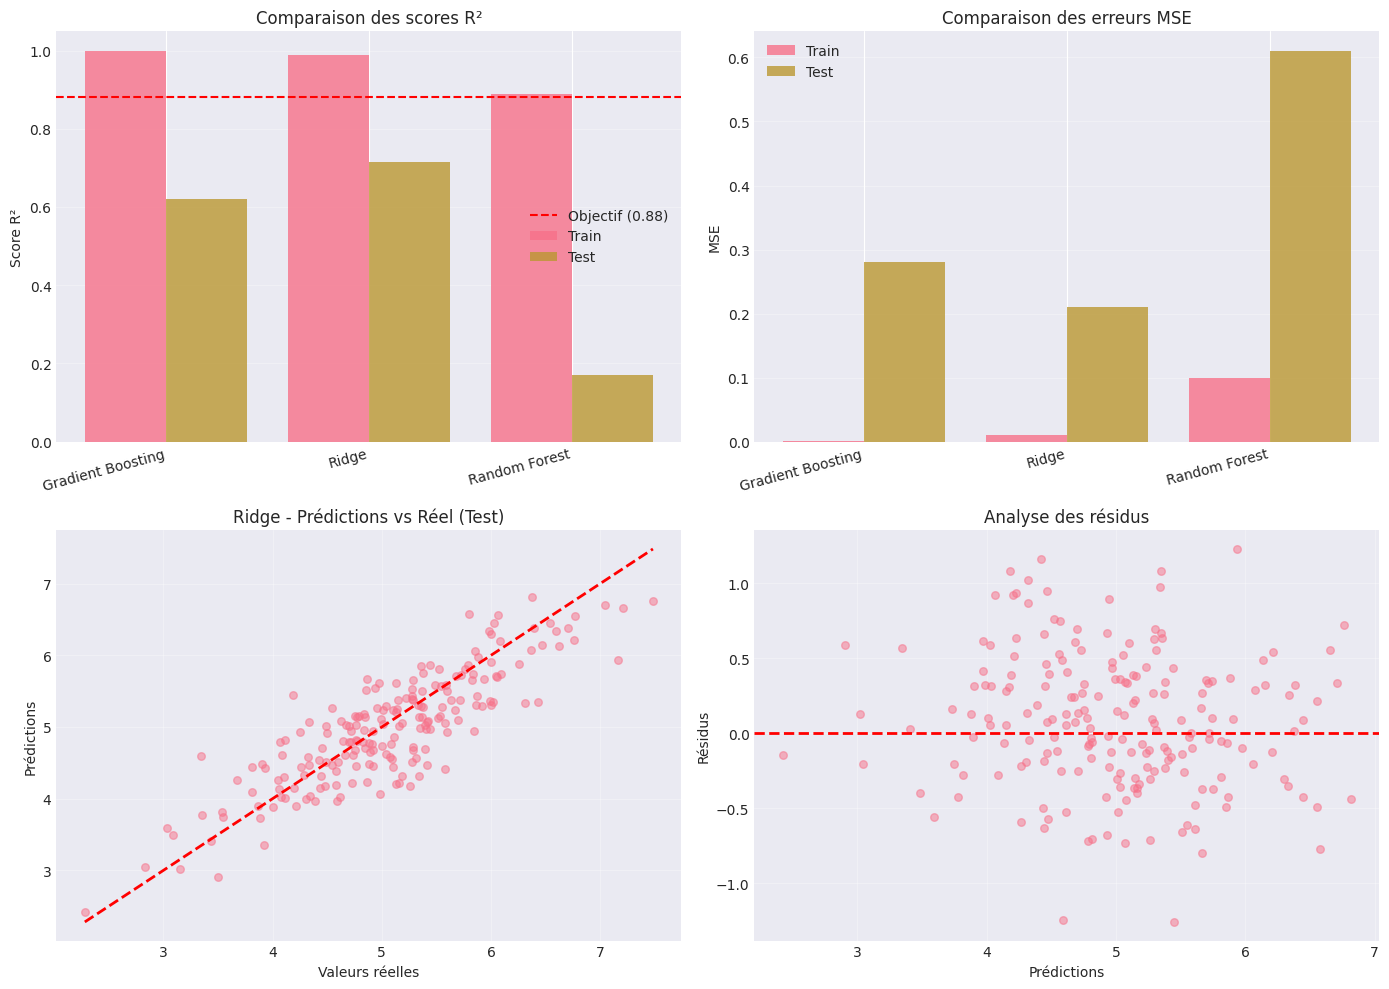

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['Gradient Boosting', 'Ridge', 'Random Forest']
x_pos = np.arange(len(models))

axes[0, 0].bar(x_pos - 0.2, [r2_train_gb, r2_train_ridge, r2_train_rf], 0.4, label='Train', alpha=0.8)
axes[0, 0].bar(x_pos + 0.2, [r2_test_gb, r2_test_ridge, r2_test_rf], 0.4, label='Test', alpha=0.8)
axes[0, 0].axhline(y=0.88, color='red', linestyle='--', label='Objectif (0.88)')
axes[0, 0].set_ylabel('Score R²')
axes[0, 0].set_title('Comparaison des scores R²')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(x_pos - 0.2, [mse_train_gb, mse_train_ridge, mse_train_rf], 0.4, label='Train', alpha=0.8)
axes[0, 1].bar(x_pos + 0.2, [mse_test_gb, mse_test_ridge, mse_test_rf], 0.4, label='Test', alpha=0.8)
axes[0, 1].set_ylabel('MSE')
axes[0, 1].set_title('Comparaison des erreurs MSE')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models, rotation=15, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

if best_idx == 0:
    y_pred = y_test_pred_gb.flatten()
    title = 'Gradient Boosting - Prédictions vs Réel (Test)'
elif best_idx == 1:
    y_pred = y_test_pred_ridge.flatten()
    title = 'Ridge - Prédictions vs Réel (Test)'
else:
    y_pred = y_test_pred_rf.flatten()
    title = 'Random Forest - Prédictions vs Réel (Test)'

y_test_flat = np.asarray(y_test).flatten()

axes[1, 0].scatter(y_test_flat, y_pred, alpha=0.5, s=30)
axes[1, 0].plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Valeurs réelles')
axes[1, 0].set_ylabel('Prédictions')
axes[1, 0].set_title(title)
axes[1, 0].grid(alpha=0.3)

residuals = (y_test_flat - y_pred).flatten()
axes[1, 1].scatter(y_pred, residuals, alpha=0.5, s=30)
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Prédictions')
axes[1, 1].set_ylabel('Résidus')
axes[1, 1].set_title('Analyse des résidus')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



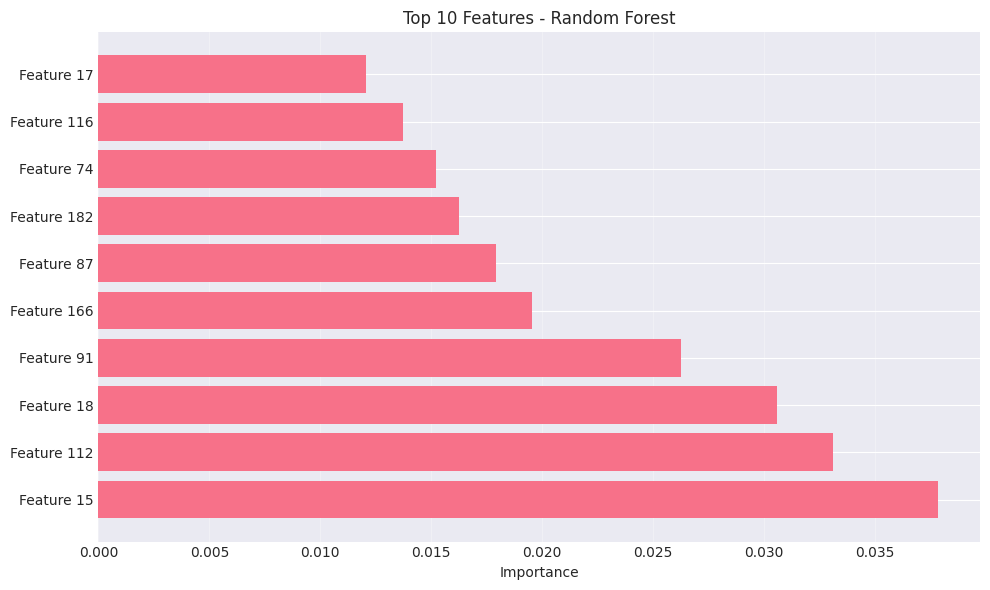


Importance des features (Random Forest):
  Feature 15: 0.037843
  Feature 112: 0.033125
  Feature 18: 0.030582
  Feature 91: 0.026242
  Feature 166: 0.019543
  Feature 87: 0.017931
  Feature 182: 0.016258
  Feature 74: 0.015212
  Feature 116: 0.013720
  Feature 17: 0.012038


In [60]:
feature_importance = rf_best.feature_importances_
feature_names = [f'Feature {i}' for i in range(len(feature_importance))]

sorted_idx = np.argsort(feature_importance)[::-1][:10]  # Top 10

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('Importance')
ax.set_title('Top 10 Features - Random Forest')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nImportance des features (Random Forest):")
for idx in sorted_idx:
    print(f"  {feature_names[idx]}: {feature_importance[idx]:.6f}")

In [61]:
if best_idx == 0:
    model_final = gb_best
    X_data = X_train
    model_name = "Gradient Boosting"
elif best_idx == 1:
    model_final = ridge_best
    X_data = X_train_scaled
    model_name = "Ridge"
else:
    model_final = rf_best
    X_data = X_train
    model_name = "Random Forest"

cv_scores = cross_val_score(model_final, X_data, y_train, cv=5, scoring='r2')

print(f"\n=== Validation Croisée (5-Fold) - {model_name} ===")
print(f"R² scores: {cv_scores}")
print(f"Moyenne CV R²: {cv_scores.mean():.6f}")
print(f"Std CV R²: {cv_scores.std():.6f}")
print(f"Min CV R²: {cv_scores.min():.6f}")
print(f"Max CV R²: {cv_scores.max():.6f}")


=== Validation Croisée (5-Fold) - Ridge ===
R² scores: [0.45834783 0.41787035 0.75209738 0.72560879 0.50042952]
Moyenne CV R²: 0.570871
Std CV R²: 0.139871
Min CV R²: 0.417870
Max CV R²: 0.752097


In [62]:
# Résumé final
print("RÉSUMÉ FINAL")
print(f"\nMeilleur modèle sélectionné : {best_model_name}")
print(f"Performance sur le test set : R² = {best_r2_test:.6f}")
print(f"Objectif (R² ≥ 0.88) : {'ATTEINT' if best_r2_test >= 0.88 else 'NON ATTEINT'}")
print(f"\nMétriques complètes du meilleur modèle sur le test set:")
print(f"  - R² Score: {best_r2_test:.6f}")
print(f"  - MSE: {results_df.loc[best_idx, 'MSE Test']:.6f}")
print(f"  - MAE: {results_df.loc[best_idx, 'MAE Test']:.6f}")
print(f"  - RMSE: {np.sqrt(results_df.loc[best_idx, 'MSE Test']):.6f}")

RÉSUMÉ FINAL

Meilleur modèle sélectionné : Ridge
Performance sur le test set : R² = 0.713659
Objectif (R² ≥ 0.88) : NON ATTEINT

Métriques complètes du meilleur modèle sur le test set:
  - R² Score: 0.713659
  - MSE: 0.210801
  - MAE: 0.367200
  - RMSE: 0.459131
